# ============================================================================
# BLOCK 1: IMPORTS & GLOBAL DEFAULTS
# ============================================================================

In [1]:


import numpy as np
import random
import math
import time
import json
import hashlib
from collections import defaultdict
import matplotlib.pyplot as plt

# Qiskit for QRNG
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Optional: scipy for any statistical needs
from scipy.special import comb

print("=" * 70)
print("QUANTUM KEY DISTRIBUTION WITH QRNG & QPP ENCRYPTION")
print("=" * 70)

# ============================================================================
# CONFIGURABLE PARAMETERS
# ============================================================================

# BB84 Simulation Parameters
N_PULSES = 20000                    # Number of pulses to simulate
TARGET_KEY_BITS = 128               # Target final key length in bits

# Decoy-state intensities (mean photon numbers)
MU_SIGNAL = 0.8
MU_DECOY = 0.2
MU_VAC = 0.0

# Intensity selection probabilities
INTENSITY_PROBS = {
    'signal': 0.6,
    'decoy': 0.3,
    'vacuum': 0.1
}

# Channel & detector parameters
CHANNEL_TRANSMITTANCE = 0.25        # Fiber loss parameter (eta)
DETECTOR_EFFICIENCY = 0.4           # Detector quantum efficiency
DARK_COUNT = 1e-5                   # Dark count probability per pulse
QBER_INTRINSIC = 0.01              # Intrinsic misalignment error rate

# PNS Attack Configuration
ENABLE_PNS = False                  # Default: baseline run without PNS
PNS_KEEP_PROB = 0.8                # Probability Eve keeps 1 photon in PNS

# Reproducibility (optional - uncomment to enable)
# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)
# random.seed(RANDOM_SEED)

print(f"\nConfiguration loaded:")
print(f"  N_PULSES = {N_PULSES}")
print(f"  TARGET_KEY_BITS = {TARGET_KEY_BITS}")
print(f"  Intensities: signal={MU_SIGNAL}, decoy={MU_DECOY}, vacuum={MU_VAC}")
print(f"  Channel transmittance = {CHANNEL_TRANSMITTANCE}")
print(f"  ENABLE_PNS = {ENABLE_PNS}")




QUANTUM KEY DISTRIBUTION WITH QRNG & QPP ENCRYPTION

Configuration loaded:
  N_PULSES = 20000
  TARGET_KEY_BITS = 128
  Intensities: signal=0.8, decoy=0.2, vacuum=0.0
  Channel transmittance = 0.25
  ENABLE_PNS = False


# ============================================================================
# BLOCK 2: DECOY-STATE BB84 SIMULATION
# ============================================================================

In [2]:


def sample_photon_number(mu):
    """
    Sample photon number from Poisson distribution with mean mu.
    
    Args:
        mu: Mean photon number (intensity parameter)
    
    Returns:
        int: Number of photons in this pulse
    """
    if mu == 0:
        return 0
    return np.random.poisson(mu)


def select_intensity():
    """
    Randomly select intensity level based on INTENSITY_PROBS.
    
    Returns:
        tuple: (intensity_type, mu_value)
    """
    rand = random.random()
    cumulative = 0
    for intensity_type, prob in INTENSITY_PROBS.items():
        cumulative += prob
        if rand < cumulative:
            if intensity_type == 'signal':
                return ('signal', MU_SIGNAL)
            elif intensity_type == 'decoy':
                return ('decoy', MU_DECOY)
            else:  # vacuum
                return ('vacuum', MU_VAC)
    return ('signal', MU_SIGNAL)  # Fallback


def apply_channel_and_detection(n_photons_sent, alice_bit, alice_basis):
    """
    Simulate quantum channel transmission and detection.
    
    Includes:
    - Channel loss (binomial thinning with CHANNEL_TRANSMITTANCE)
    - Detector efficiency
    - Dark counts
    - Intrinsic bit errors (misalignment)
    - Optional PNS attack
    
    Args:
        n_photons_sent: Number of photons Alice sends
        alice_bit: Alice's bit value (0 or 1)
        alice_basis: Alice's basis choice ('Z' or 'X')
    
    Returns:
        tuple: (detected_flag, detected_bit, n_photons_after_channel, pns_occurred)
    """
    pns_occurred = False
    n_photons = n_photons_sent
    
    # PNS Attack: Eve intercepts if n_photons >= 2
    if ENABLE_PNS and n_photons >= 2:
        if random.random() < PNS_KEEP_PROB:
            pns_occurred = True
            n_photons = n_photons - 1  # Eve keeps 1 photon
    
    # Channel loss: binomial thinning
    if n_photons > 0:
        n_photons_transmitted = np.random.binomial(n_photons, CHANNEL_TRANSMITTANCE)
    else:
        n_photons_transmitted = 0
    
    # Detector efficiency
    if n_photons_transmitted > 0:
        n_photons_detected = np.random.binomial(n_photons_transmitted, DETECTOR_EFFICIENCY)
    else:
        n_photons_detected = 0
    
    # Dark count
    has_dark_count = random.random() < DARK_COUNT
    
    # Detection event occurs if photons detected OR dark count
    detected = (n_photons_detected > 0) or has_dark_count
    
    if not detected:
        return (False, None, n_photons_transmitted, pns_occurred)
    
    # Bob randomly chooses basis
    bob_basis = random.choice(['Z', 'X'])
    
    # If bases match, Bob measures Alice's bit (with intrinsic errors)
    # If bases don't match, result is random
    if bob_basis == alice_basis:
        # Correct basis: Bob should get Alice's bit (with errors)
        if random.random() < QBER_INTRINSIC:
            detected_bit = 1 - alice_bit  # Bit flip error
        else:
            detected_bit = alice_bit
    else:
        # Wrong basis: random outcome
        detected_bit = random.choice([0, 1])
    
    # Dark counts produce random bits
    if has_dark_count and n_photons_detected == 0:
        detected_bit = random.choice([0, 1])
    
    return (detected, detected_bit, n_photons_transmitted, pns_occurred)


def run_single_pulse():
    """
    Simulate a single BB84 pulse with decoy-state protocol.
    
    Returns:
        dict: Event record containing all relevant information
    """
    # Alice's random choices
    alice_bit = random.choice([0, 1])
    alice_basis = random.choice(['Z', 'X'])
    
    # Select intensity for this pulse
    intensity_type, mu = select_intensity()
    
    # Sample photon number
    n_photons = sample_photon_number(mu)
    
    # Channel and detection
    detected, detected_bit, n_photons_after, pns_occurred = apply_channel_and_detection(
        n_photons, alice_bit, alice_basis
    )
    
    # Bob's basis (already chosen in detection function, but record here)
    # For sifting, we need Bob to announce his basis choice
    bob_basis = random.choice(['Z', 'X'])  # Re-sample for record
    
    event = {
        'alice_bit': alice_bit,
        'alice_basis': alice_basis,
        'bob_basis': bob_basis,
        'intensity_type': intensity_type,
        'mu': mu,
        'n_photons': n_photons,
        'n_photons_after_channel': n_photons_after,
        'detected': detected,
        'detected_bit': detected_bit,
        'pns_occurred': pns_occurred,
        'basis_match': (alice_basis == bob_basis)
    }
    
    return event


def run_bb84_simulation(n_pulses):
    """
    Run full BB84 simulation for n_pulses.
    
    Args:
        n_pulses: Number of pulses to simulate
    
    Returns:
        list: List of event dictionaries
    """
    print(f"\n{'='*70}")
    print(f"Running BB84 simulation with {n_pulses} pulses...")
    print(f"{'='*70}")
    
    events = []
    for i in range(n_pulses):
        # For proper BB84, Bob needs to independently choose basis
        # Modify single pulse to properly track Bob's choice
        alice_bit = random.choice([0, 1])
        alice_basis = random.choice(['Z', 'X'])
        intensity_type, mu = select_intensity()
        n_photons = sample_photon_number(mu)
        
        # Bob independently chooses basis
        bob_basis = random.choice(['Z', 'X'])
        
        # Simulate detection (this internally uses Bob's basis for measurement)
        detected, detected_bit, n_after, pns = apply_channel_and_detection(
            n_photons, alice_bit, alice_basis
        )
        
        # For basis matching, Bob measures in his chosen basis
        # If bases match and detection occurs, we use the detected bit
        # Need to recalculate detected_bit with Bob's actual basis
        if detected:
            if bob_basis == alice_basis:
                # Correct basis match
                if random.random() < QBER_INTRINSIC:
                    detected_bit = 1 - alice_bit
                else:
                    detected_bit = alice_bit
            else:
                # Basis mismatch - random
                detected_bit = random.choice([0, 1])
        
        event = {
            'alice_bit': alice_bit,
            'alice_basis': alice_basis,
            'bob_basis': bob_basis,
            'intensity_type': intensity_type,
            'mu': mu,
            'n_photons': n_photons,
            'n_photons_after_channel': n_after,
            'detected': detected,
            'detected_bit': detected_bit,
            'pns_occurred': pns,
            'basis_match': (alice_basis == bob_basis)
        }
        events.append(event)
    
    # Summary statistics
    total_detected = sum(1 for e in events if e['detected'])
    basis_matched = sum(1 for e in events if e['detected'] and e['basis_match'])
    pns_count = sum(1 for e in events if e['pns_occurred'])
    
    print(f"\nSimulation complete:")
    print(f"  Total pulses sent: {n_pulses}")
    print(f"  Detected pulses: {total_detected} ({100*total_detected/n_pulses:.2f}%)")
    print(f"  Basis matched (siftable): {basis_matched} ({100*basis_matched/n_pulses:.2f}%)")
    if ENABLE_PNS:
        print(f"  PNS attacks occurred: {pns_count}")
    
    return events


def extract_sifted_key(events):
    """
    Extract sifted key bits from BB84 events.
    
    Sifting: Keep only events where bases matched AND detection occurred.
    
    Args:
        events: List of BB84 event dictionaries
    
    Returns:
        tuple: (alice_sifted_bits, bob_sifted_bits, sifted_events)
    """
    alice_sifted = []
    bob_sifted = []
    sifted_events = []
    
    for event in events:
        if event['detected'] and event['basis_match']:
            alice_sifted.append(event['alice_bit'])
            bob_sifted.append(event['detected_bit'])
            sifted_events.append(event)
    
    print(f"\nKey sifting complete:")
    print(f"  Sifted key length: {len(alice_sifted)} bits")
    
    return np.array(alice_sifted), np.array(bob_sifted), sifted_events


def compute_intensity_statistics(events):
    """
    Compute per-intensity gain (Q_mu) and QBER (E_mu).
    
    Args:
        events: List of BB84 event dictionaries
    
    Returns:
        dict: Statistics per intensity type
    """
    stats = defaultdict(lambda: {'sent': 0, 'detected': 0, 'errors': 0, 'sifted': 0})
    
    for event in events:
        intensity = event['intensity_type']
        stats[intensity]['sent'] += 1
        
        if event['detected']:
            stats[intensity]['detected'] += 1
            
            if event['basis_match']:
                stats[intensity]['sifted'] += 1
                if event['alice_bit'] != event['detected_bit']:
                    stats[intensity]['errors'] += 1
    
    # Compute Q_mu (gain) and E_mu (QBER) per intensity
    results = {}
    for intensity, data in stats.items():
        Q_mu = data['detected'] / data['sent'] if data['sent'] > 0 else 0
        E_mu = data['errors'] / data['sifted'] if data['sifted'] > 0 else 0
        
        results[intensity] = {
            'Q_mu': Q_mu,
            'E_mu': E_mu,
            'sent': data['sent'],
            'detected': data['detected'],
            'sifted': data['sifted'],
            'errors': data['errors']
        }
    
    return results


def estimate_yields_decoy_state(events):
    """
    Estimate photon-number-dependent yields Y_n using decoy-state method.
    
    Uses truncated photon number (n=0,1,2) approximation:
    Q_mu = sum_n [ P(n|mu) * Y_n ]
    
    where P(n|mu) = (mu^n / n!) * exp(-mu) is Poisson distribution.
    
    Args:
        events: List of BB84 event dictionaries
    
    Returns:
        dict: Estimated yields {Y0, Y1, Y2, e1}
    """
    print(f"\n{'='*70}")
    print("DECOY-STATE ANALYSIS")
    print(f"{'='*70}")
    
    intensity_stats = compute_intensity_statistics(events)
    
    # Get observed gains for each intensity
    Q_signal = intensity_stats['signal']['Q_mu']
    Q_decoy = intensity_stats['decoy']['Q_mu']
    Q_vacuum = intensity_stats['vacuum']['Q_mu']
    
    print(f"\nObserved gains (Q_mu):")
    print(f"  Q_signal (mu={MU_SIGNAL}): {Q_signal:.6f}")
    print(f"  Q_decoy (mu={MU_DECOY}): {Q_decoy:.6f}")
    print(f"  Q_vacuum (mu={MU_VAC}): {Q_vacuum:.6f}")
    
    # Poisson probabilities for each intensity
    def poisson_prob(n, mu):
        if mu == 0:
            return 1.0 if n == 0 else 0.0
        return (mu**n / math.factorial(n)) * math.exp(-mu)
    
    # System of equations (truncated to n=0,1,2):
    # Q_signal = P0_s*Y0 + P1_s*Y1 + P2_s*Y2
    # Q_decoy = P0_d*Y0 + P1_d*Y1 + P2_d*Y2
    # Q_vacuum = Y0 (since mu=0)
    
    # Estimate Y0 from vacuum
    Y0_est = Q_vacuum
    
    # For signal intensity
    P0_signal = poisson_prob(0, MU_SIGNAL)
    P1_signal = poisson_prob(1, MU_SIGNAL)
    P2_signal = poisson_prob(2, MU_SIGNAL)
    
    # For decoy intensity
    P0_decoy = poisson_prob(0, MU_DECOY)
    P1_decoy = poisson_prob(1, MU_DECOY)
    P2_decoy = poisson_prob(2, MU_DECOY)
    
    # Solve for Y1 and Y2
    # From decoy: Q_decoy - P0_d*Y0 = P1_d*Y1 + P2_d*Y2
    # From signal: Q_signal - P0_s*Y0 = P1_s*Y1 + P2_s*Y2
    
    # Simple linear solve (2x2 system)
    # P1_d*Y1 + P2_d*Y2 = Q_decoy - P0_d*Y0
    # P1_s*Y1 + P2_s*Y2 = Q_signal - P0_s*Y0
    
    b1 = Q_decoy - P0_decoy * Y0_est
    b2 = Q_signal - P0_signal * Y0_est
    
    # Solve using Cramer's rule or numpy
    A = np.array([
        [P1_decoy, P2_decoy],
        [P1_signal, P2_signal]
    ])
    b = np.array([b1, b2])
    
    try:
        Y_solution = np.linalg.solve(A, b)
        Y1_est = max(0, Y_solution[0])  # Ensure non-negative
        Y2_est = max(0, Y_solution[1])
    except np.linalg.LinAlgError:
        print("Warning: Singular matrix in decoy-state solve, using fallback estimates")
        Y1_est = max(0, b1 / P1_decoy) if P1_decoy > 0 else 0
        Y2_est = 0
    
    # Estimate e1 (single-photon error rate) from intensity stats
    # Crude approximation: use signal QBER as upper bound
    e1_est = intensity_stats['signal']['E_mu']
    
    print(f"\nEstimated yields:")
    print(f"  Y0 (vacuum yield): {Y0_est:.6f}")
    print(f"  Y1 (single-photon yield): {Y1_est:.6f}")
    print(f"  Y2 (two-photon yield): {Y2_est:.6f}")
    print(f"  e1 (single-photon QBER): {e1_est:.6f}")
    
    return {
        'Y0': Y0_est,
        'Y1': Y1_est,
        'Y2': Y2_est,
        'e1': e1_est,
        'intensity_stats': intensity_stats
    }


print("\n" + "="*70)
print("BLOCK 2 COMPLETE: BB84 Simulation Functions Ready")
print("="*70)


BLOCK 2 COMPLETE: BB84 Simulation Functions Ready


# ============================================================================
# BLOCK 3: QRNG AND FINAL KEY COMPOSITION (NOVELTY 1)
# ============================================================================

In [3]:


def qrng_generate_bits(n_bits, use_fixed_seed=False):
    """
    Generate true quantum random bits using Qiskit AerSimulator.
    
    Uses quantum superposition: |0> -> H -> measure
    Each measurement collapses the superposition, yielding true quantum randomness.
    
    NOTE: QRNG is considered true quantum randomness by design (measurement collapse).
    No additional statistical tests are performed in this work.
    
    Args:
        n_bits: Number of random bits to generate
        use_fixed_seed: If True, use seed=42 for reproducibility (testing only)
    
    Returns:
        numpy.ndarray: Array of random bits (0s and 1s)
    """
    print(f"\nGenerating {n_bits} quantum random bits using QRNG...")
    
    # Create quantum circuit with 1 qubit
    qc = QuantumCircuit(1, 1)
    qc.h(0)  # Hadamard gate creates superposition
    qc.measure(0, 0)
    
    # Set up simulator
    if use_fixed_seed:
        simulator = AerSimulator(seed_simulator=42)
    else:
        simulator = AerSimulator()
    
    # Run circuit n_bits times to get n_bits measurements
    job = simulator.run(qc, shots=n_bits, memory=True)
    result = job.result()
    
    # Extract measurement results
    measurements = result.get_memory()
    bits = np.array([int(m) for m in measurements], dtype=np.uint8)
    
    print(f"QRNG generation complete: {len(bits)} bits")
    
    return bits


def qrng_sanity_check(bits):
    """
    Perform basic sanity checks on QRNG output.
    
    NOTE: These are quick sanity checks only. Full statistical testing
    is not performed as QRNG is considered quantum-true randomness.
    
    Args:
        bits: numpy array of bits
    
    Returns:
        dict: Sanity check results
    """
    n = len(bits)
    ones_count = np.sum(bits)
    ones_ratio = ones_count / n if n > 0 else 0
    
    # Check adjacent bit equality ratio
    if n > 1:
        adjacent_equal = np.sum(bits[:-1] == bits[1:])
        adjacent_equal_ratio = adjacent_equal / (n - 1)
    else:
        adjacent_equal_ratio = 0
    
    results = {
        'total_bits': n,
        'ones_count': int(ones_count),
        'ones_ratio': ones_ratio,
        'adjacent_equal_ratio': adjacent_equal_ratio
    }
    
    print(f"\nQRNG Sanity Check:")
    print(f"  Total bits: {n}")
    print(f"  Ones ratio: {ones_ratio:.4f} (expect ~0.5)")
    print(f"  Adjacent equal ratio: {adjacent_equal_ratio:.4f} (expect ~0.5)")
    
    return results


def expand_key_bits(raw_bits, target_bits):
    """
    Expand key material to target length using SHA256 counter mode.
    
    This is a deterministic key derivation function (KDF).
    
    Args:
        raw_bits: numpy array of bits to expand
        target_bits: desired output length in bits
    
    Returns:
        numpy.ndarray: Expanded key bits
    """
    if len(raw_bits) >= target_bits:
        return raw_bits[:target_bits]
    
    print(f"\nExpanding key from {len(raw_bits)} to {target_bits} bits using SHA256-KDF...")
    
    # Convert bits to bytes for hashing
    raw_bytes = np.packbits(raw_bits)
    
    expanded_bits = []
    counter = 0
    
    while len(expanded_bits) < target_bits:
        # Hash (raw_bytes || counter)
        h = hashlib.sha256()
        h.update(raw_bytes.tobytes())
        h.update(counter.to_bytes(4, 'big'))
        hash_bytes = h.digest()
        
        # Convert hash to bits
        hash_bits = np.unpackbits(np.frombuffer(hash_bytes, dtype=np.uint8))
        expanded_bits.extend(hash_bits)
        
        counter += 1
    
    result = np.array(expanded_bits[:target_bits], dtype=np.uint8)
    print(f"Key expansion complete: {len(result)} bits")
    
    return result


def derive_final_key(events):
    """
    Derive final cryptographic key using NOVELTY 1:
    
    NOVELTY 1: XOR BB84 sifted bits with QRNG bits for enhanced security.
    final_key = bb84_sifted_bits ⊕ qrng_bits
    
    This combines quantum communication security (BB84) with quantum
    measurement randomness (QRNG), providing dual quantum security layers.
    
    Args:
        events: List of BB84 event dictionaries
    
    Returns:
        tuple: (final_key_bits, bb84_bits, qrng_bits, metadata)
    """
    print(f"\n{'='*70}")
    print("FINAL KEY DERIVATION (NOVELTY 1: BB84 ⊕ QRNG)")
    print(f"{'='*70}")
    
    # Extract sifted bits from BB84
    alice_sifted, bob_sifted, sifted_events = extract_sifted_key(events)
    
    # Use Alice's bits as protocol key (in real QKD, error correction would reconcile)
    bb84_bits = alice_sifted
    K = len(bb84_bits)
    
    if K == 0:
        print("WARNING: No sifted bits available, cannot derive key")
        return np.array([], dtype=np.uint8), np.array([]), np.array([]), {}
    
    print(f"\nBB84 protocol key length: {K} bits")
    
    # Generate QRNG bits of same length
    qrng_bits = qrng_generate_bits(K)
    
    # Perform QRNG sanity check
    qrng_stats = qrng_sanity_check(qrng_bits)
    
    # NOVELTY 1: XOR BB84 bits with QRNG bits
    print(f"\n[NOVELTY 1] XORing BB84 key with QRNG bits...")
    final_raw = np.bitwise_xor(bb84_bits, qrng_bits)
    
    print(f"Raw final key length: {len(final_raw)} bits")
    
    # Expand to target length if needed
    if len(final_raw) < TARGET_KEY_BITS:
        print(f"Expanding key to target length {TARGET_KEY_BITS} bits...")
        final_key_bits = expand_key_bits(final_raw, TARGET_KEY_BITS)
    else:
        final_key_bits = final_raw[:TARGET_KEY_BITS]
    
    metadata = {
        'bb84_sifted_length': K,
        'final_key_length': len(final_key_bits),
        'qrng_stats': qrng_stats,
        'expansion_applied': len(final_raw) < TARGET_KEY_BITS
    }
    
    print(f"\nFinal key derivation complete:")
    print(f"  Final key length: {len(final_key_bits)} bits")
    print(f"  Expansion applied: {metadata['expansion_applied']}")
    
    return final_key_bits, bb84_bits, qrng_bits, metadata




# ============================================================================
# BLOCK 4: QPP ENCRYPTION WITH DYNAMIC PER-BLOCK SEEDING (NOVELTY 2)
# ============================================================================

In [4]:


def bits_to_bytes(bits):
    """Convert bit array to bytes."""
    return np.packbits(bits).tobytes()


def bytes_to_bits(byte_data):
    """Convert bytes to bit array."""
    return np.unpackbits(np.frombuffer(byte_data, dtype=np.uint8))


def derive_session_seed(final_key_bits):
    """
    Derive session seed from final key using SHA256.
    
    Args:
        final_key_bits: numpy array of key bits
    
    Returns:
        bytes: 32-byte session seed
    """
    key_bytes = bits_to_bytes(final_key_bits)
    session_seed = hashlib.sha256(key_bytes).digest()
    return session_seed


def derive_block_seed(session_seed, block_index):
    """
    Derive per-block seed using hierarchical key derivation.
    
    NOVELTY 2: Each block gets unique seed = SHA256(session_seed || block_index)
    
    Args:
        session_seed: bytes, master session seed
        block_index: int, index of current block
    
    Returns:
        int: Block-specific seed for RNG
    """
    h = hashlib.sha256()
    h.update(session_seed)
    h.update(block_index.to_bytes(8, 'big'))
    block_seed_bytes = h.digest()
    # Convert to integer seed
    block_seed_int = int.from_bytes(block_seed_bytes[:8], 'big')
    return block_seed_int


def qpp_encrypt(plaintext_bytes, final_key_bits):
    """
    Encrypt using Quantum Permutation Pad with dynamic per-block seeding.
    
    NOVELTY 2: Each block uses unique seed derived from session key + block index.
    This prevents pattern leakage across blocks and enhances security.
    
    Algorithm:
    1. Derive session seed from final_key_bits
    2. Split plaintext into blocks (block_size = len(final_key_bits)//8 bytes, min 1)
    3. For each block, derive unique block seed
    4. Generate seeded permutation for that block
    5. Apply permutation to block bytes
    
    Args:
        plaintext_bytes: bytes to encrypt
        final_key_bits: numpy array of final key bits
    
    Returns:
        bytes: Encrypted ciphertext
    """
    print(f"\n{'='*70}")
    print("QPP ENCRYPTION (NOVELTY 2: Dynamic Per-Block Seeding)")
    print(f"{'='*70}")
    
    if len(plaintext_bytes) == 0:
        return b''
    
    # Derive session seed
    session_seed = derive_session_seed(final_key_bits)
    print(f"Session seed derived: {session_seed[:8].hex()}...")
    
    # Determine block size (in bytes)
    block_size = max(1, len(final_key_bits) // 8)
    print(f"Block size: {block_size} bytes")
    
    # Pad plaintext to multiple of block_size
    padding_needed = (block_size - (len(plaintext_bytes) % block_size)) % block_size
    if padding_needed > 0:
        plaintext_padded = plaintext_bytes + bytes([padding_needed] * padding_needed)
    else:
        plaintext_padded = plaintext_bytes
    
    print(f"Plaintext length: {len(plaintext_bytes)} bytes")
    print(f"Padded length: {len(plaintext_padded)} bytes")
    
    # Encrypt block by block
    ciphertext_blocks = []
    num_blocks = len(plaintext_padded) // block_size
    
    print(f"Processing {num_blocks} blocks...")
    
    for block_idx in range(num_blocks):
        # Extract block
        start = block_idx * block_size
        end = start + block_size
        block = plaintext_padded[start:end]
        
        # NOVELTY 2: Derive unique seed for this block
        block_seed = derive_block_seed(session_seed, block_idx)
        
        # Generate permutation using block-specific seed
        rng = random.Random(block_seed)
        permutation = list(range(block_size))
        rng.shuffle(permutation)
        
        # Apply permutation
        block_array = np.frombuffer(block, dtype=np.uint8)
        encrypted_block = block_array[permutation]
        ciphertext_blocks.append(encrypted_block.tobytes())
    
    ciphertext = b''.join(ciphertext_blocks)
    print(f"Encryption complete: {len(ciphertext)} bytes")
    
    return ciphertext


def qpp_decrypt(ciphertext_bytes, final_key_bits):
    """
    Decrypt QPP ciphertext using dynamic per-block seeding.
    
    Uses same hierarchical seed derivation as encryption to reconstruct
    permutations and apply inverse permutations.
    
    Args:
        ciphertext_bytes: bytes to decrypt
        final_key_bits: numpy array of final key bits (same as encryption)
    
    Returns:
        bytes: Decrypted plaintext
    """
    print(f"\n{'='*70}")
    print("QPP DECRYPTION")
    print(f"{'='*70}")
    
    if len(ciphertext_bytes) == 0:
        return b''
    
    # Derive session seed (same as encryption)
    session_seed = derive_session_seed(final_key_bits)
    
    # Block size (same as encryption)
    block_size = max(1, len(final_key_bits) // 8)
    print(f"Block size: {block_size} bytes")
    
    # Decrypt block by block
    plaintext_blocks = []
    num_blocks = len(ciphertext_bytes) // block_size
    
    print(f"Processing {num_blocks} blocks...")
    
    for block_idx in range(num_blocks):
        # Extract block
        start = block_idx * block_size
        end = start + block_size
        block = ciphertext_bytes[start:end]
        
        # Derive same block seed
        block_seed = derive_block_seed(session_seed, block_idx)
        
        # Generate same permutation
        rng = random.Random(block_seed)
        permutation = list(range(block_size))
        rng.shuffle(permutation)
        
        # Create inverse permutation
        inverse_perm = [0] * block_size
        for i, p in enumerate(permutation):
            inverse_perm[p] = i
        
        # Apply inverse permutation
        block_array = np.frombuffer(block, dtype=np.uint8)
        decrypted_block = block_array[inverse_perm]
        plaintext_blocks.append(decrypted_block.tobytes())
    
    plaintext_padded = b''.join(plaintext_blocks)
    
    # Remove padding
    if len(plaintext_padded) > 0:
        padding_len = plaintext_padded[-1]
        if padding_len < block_size and all(b == padding_len for b in plaintext_padded[-padding_len:]):
            plaintext = plaintext_padded[:-padding_len]
        else:
            plaintext = plaintext_padded
    else:
        plaintext = plaintext_padded
    
    print(f"Decryption complete: {len(plaintext)} bytes")
    
    return plaintext


print("\n" + "="*70)
print("BLOCKS 3-4 COMPLETE: QRNG Key Derivation & QPP Encryption Ready")
print("="*70)
print("\nNOVELTY 1: BB84 ⊕ QRNG key composition implemented")
print("NOVELTY 2: Dynamic per-block seeding for QPP implemented")


BLOCKS 3-4 COMPLETE: QRNG Key Derivation & QPP Encryption Ready

NOVELTY 1: BB84 ⊕ QRNG key composition implemented
NOVELTY 2: Dynamic per-block seeding for QPP implemented


# ============================================================================
# BLOCK 5: METRICS, EXPERIMENTS & I/O
# ============================================================================


STARTING MAIN EXPERIMENT SEQUENCE




EXPERIMENT: BASELINE

--- Attempt 1: N_PULSES = 20000 ---

Running BB84 simulation with 20000 pulses...

Simulation complete:
  Total pulses sent: 20000
  Detected pulses: 993 (4.96%)
  Basis matched (siftable): 495 (2.48%)

DECOY-STATE ANALYSIS

Observed gains (Q_mu):
  Q_signal (mu=0.8): 0.074080
  Q_decoy (mu=0.2): 0.017972
  Q_vacuum (mu=0.0): 0.000000

Estimated yields:
  Y0 (vacuum yield): 0.000000
  Y1 (single-photon yield): 0.077645
  Y2 (two-photon yield): 0.321103
  e1 (single-photon QBER): 0.013514

FINAL KEY DERIVATION (NOVELTY 1: BB84 ⊕ QRNG)

Key sifting complete:
  Sifted key length: 495 bits

BB84 protocol key length: 495 bits

Generating 495 quantum random bits using QRNG...
QRNG generation complete: 495 bits

QRNG Sanity Check:
  Total bits: 495
  Ones ratio: 0.4949 (expect ~0.5)
  Adjacent equal ratio: 0.5405 (expect ~0.5)

[NOVELTY 1] XORing BB84 key with QRNG bits...
Raw final key length: 495 bits

Final key derivation complet

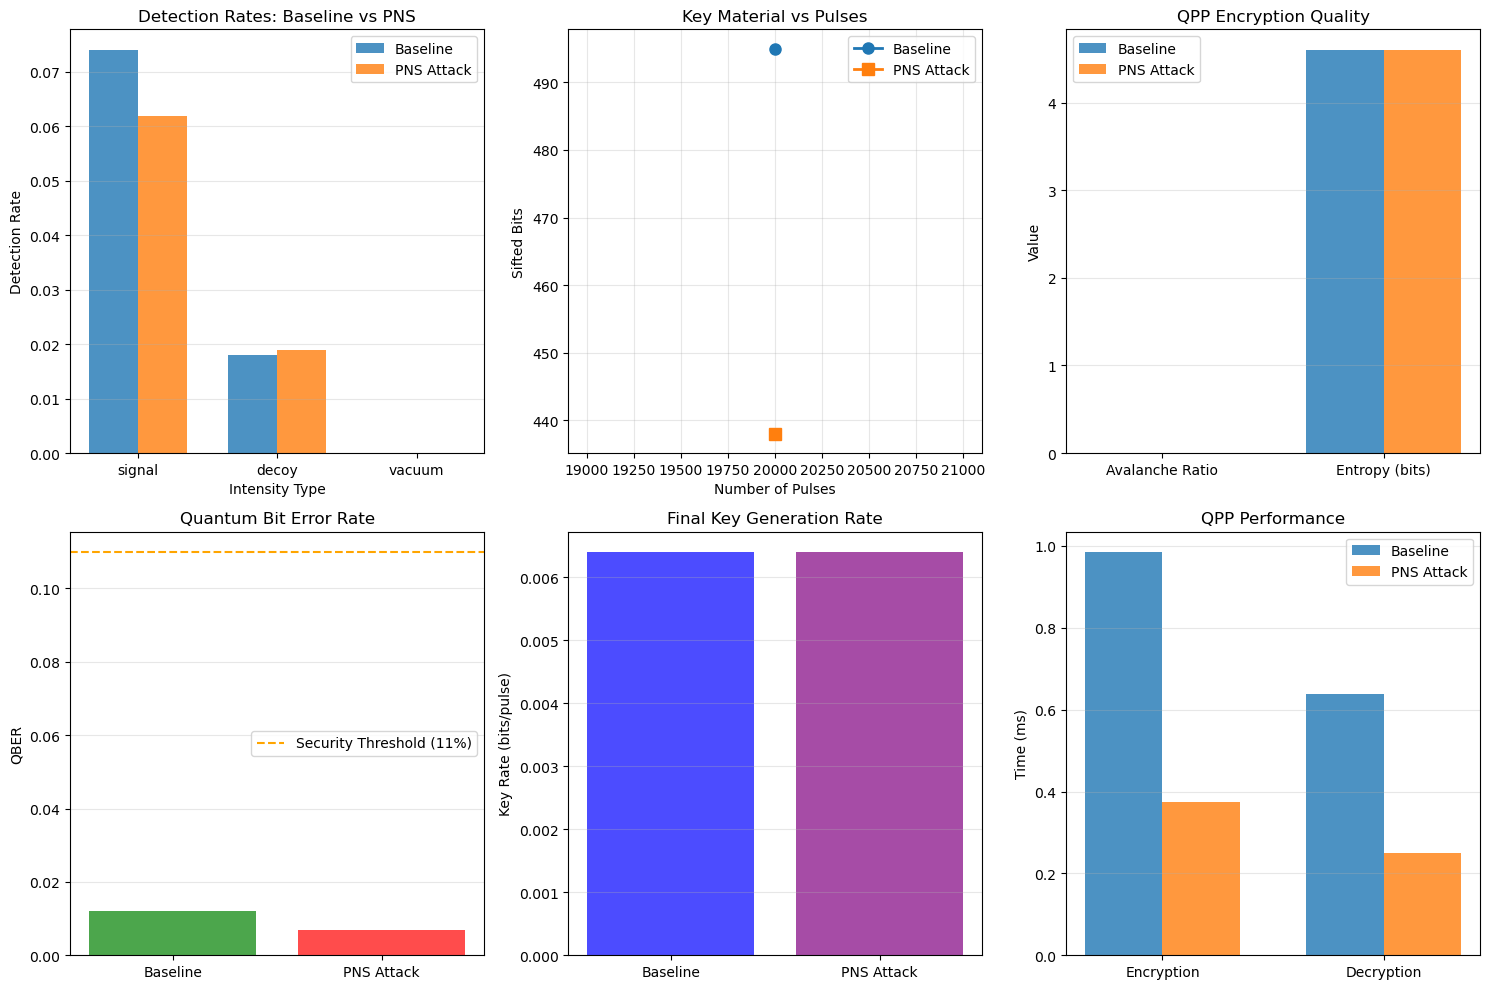


COMPREHENSIVE RESULTS SUMMARY

--- BB84 QKD METRICS ---
Metric                                Baseline      PNS Attack
----------------------------------------------------------------------
Total Pulses                             20000           20000
Detected Pulses                            993             854
Sifted Bits                                495             438
QBER                                    0.0121          0.0068
Sift Rate                               0.0248          0.0219
Final Key Length (bits)                    128             128
Key Rate (bits/pulse)                 0.006400        0.006400

--- DECOY-STATE ANALYSIS ---
Yield                                 Baseline      PNS Attack
----------------------------------------------------------------------
Y0 (vacuum)                           0.000000        0.000000
Y1 (single-photon)                    0.077645        0.097028
Y2 (two-photon)                       0.321103        0.187349
e1 (error rate)

In [5]:


def compute_bb84_metrics(events, final_key_bits):
    """
    Compute comprehensive BB84 performance metrics.
    
    Args:
        events: List of BB84 event dictionaries
        final_key_bits: numpy array of final key bits
    
    Returns:
        dict: BB84 metrics
    """
    n_pulses = len(events)
    
    # Detection statistics
    detected_events = [e for e in events if e['detected']]
    n_detected = len(detected_events)
    
    # Sifted key (basis matched)
    sifted_events = [e for e in events if e['detected'] and e['basis_match']]
    n_sifted = len(sifted_events)
    
    # QBER calculation
    if n_sifted > 0:
        errors = sum(1 for e in sifted_events if e['alice_bit'] != e['detected_bit'])
        qber = errors / n_sifted
    else:
        qber = 0
    
    # Per-intensity detection rates
    intensity_detections = defaultdict(lambda: {'sent': 0, 'detected': 0})
    for e in events:
        intensity = e['intensity_type']
        intensity_detections[intensity]['sent'] += 1
        if e['detected']:
            intensity_detections[intensity]['detected'] += 1
    
    detection_rates = {}
    for intensity, counts in intensity_detections.items():
        rate = counts['detected'] / counts['sent'] if counts['sent'] > 0 else 0
        detection_rates[intensity] = rate
    
    # Key rates
    sift_rate = n_sifted / n_pulses if n_pulses > 0 else 0
    final_key_rate = len(final_key_bits) / n_pulses if n_pulses > 0 else 0
    
    metrics = {
        'n_pulses': n_pulses,
        'n_detected': n_detected,
        'n_sifted': n_sifted,
        'qber': qber,
        'sift_rate': sift_rate,
        'detection_rates': detection_rates,
        'final_key_length': len(final_key_bits),
        'final_key_rate': final_key_rate
    }
    
    return metrics


def compute_qpp_metrics(plaintext_bytes, ciphertext_bytes, final_key_bits):
    """
    Compute QPP encryption quality metrics.
    
    Args:
        plaintext_bytes: Original plaintext
        ciphertext_bytes: Encrypted ciphertext
        final_key_bits: Encryption key
    
    Returns:
        dict: QPP metrics
    """
    metrics = {}
    
    # Timing: Encryption
    start_time = time.time()
    _ = qpp_encrypt(plaintext_bytes, final_key_bits)
    enc_time = time.time() - start_time
    metrics['encryption_time'] = enc_time
    
    # Timing: Decryption
    start_time = time.time()
    _ = qpp_decrypt(ciphertext_bytes, final_key_bits)
    dec_time = time.time() - start_time
    metrics['decryption_time'] = dec_time
    
    # Avalanche effect: flip 1 bit in plaintext
    if len(plaintext_bytes) > 0:
        plaintext_bits = bytes_to_bits(plaintext_bytes)
        flipped_bits = plaintext_bits.copy()
        flipped_bits[0] = 1 - flipped_bits[0]  # Flip first bit
        flipped_plaintext = bits_to_bytes(flipped_bits)
        
        cipher_original = qpp_encrypt(plaintext_bytes, final_key_bits)
        cipher_flipped = qpp_encrypt(flipped_plaintext, final_key_bits)
        
        # Compare ciphertexts
        cipher_orig_bits = bytes_to_bits(cipher_original)
        cipher_flip_bits = bytes_to_bits(cipher_flipped)
        
        min_len = min(len(cipher_orig_bits), len(cipher_flip_bits))
        if min_len > 0:
            diff_bits = np.sum(cipher_orig_bits[:min_len] != cipher_flip_bits[:min_len])
            avalanche_ratio = diff_bits / min_len
        else:
            avalanche_ratio = 0
    else:
        avalanche_ratio = 0
    
    metrics['avalanche_ratio'] = avalanche_ratio
    
    # Key sensitivity: flip 1 bit in key
    if len(final_key_bits) > 1:
        key_flipped = final_key_bits.copy()
        key_flipped[0] = 1 - key_flipped[0]
        
        cipher_key_orig = qpp_encrypt(plaintext_bytes, final_key_bits)
        cipher_key_flip = qpp_encrypt(plaintext_bytes, key_flipped)
        
        cipher_ko_bits = bytes_to_bits(cipher_key_orig)
        cipher_kf_bits = bytes_to_bits(cipher_key_flip)
        
        min_len = min(len(cipher_ko_bits), len(cipher_kf_bits))
        if min_len > 0:
            diff_bits = np.sum(cipher_ko_bits[:min_len] != cipher_kf_bits[:min_len])
            key_sensitivity = diff_bits / min_len
        else:
            key_sensitivity = 0
    else:
        key_sensitivity = 0
    
    metrics['key_sensitivity'] = key_sensitivity
    
    # Ciphertext entropy (Shannon entropy per byte)
    if len(ciphertext_bytes) > 0:
        byte_counts = np.bincount(np.frombuffer(ciphertext_bytes, dtype=np.uint8), minlength=256)
        byte_probs = byte_counts / len(ciphertext_bytes)
        byte_probs = byte_probs[byte_probs > 0]  # Remove zeros
        entropy = -np.sum(byte_probs * np.log2(byte_probs))
    else:
        entropy = 0
    
    metrics['ciphertext_entropy'] = entropy
    
    # Bit frequency (1s vs 0s)
    if len(ciphertext_bytes) > 0:
        cipher_bits = bytes_to_bits(ciphertext_bytes)
        ones_ratio = np.sum(cipher_bits) / len(cipher_bits)
    else:
        ones_ratio = 0
    
    metrics['ciphertext_ones_ratio'] = ones_ratio
    
    # Permutation uniformity (check if permutation is well-distributed)
    # This is implicit in the seeded shuffle - we just note it was used
    metrics['permutation_method'] = 'seeded_shuffle_per_block'
    
    return metrics


def save_artifacts(plaintext_bytes, ciphertext_bytes, final_key_bits):
    """
    Save plaintext, ciphertext, and final key to files.
    Falls back to printing hex if file I/O fails.
    
    Args:
        plaintext_bytes: Plaintext data
        ciphertext_bytes: Ciphertext data
        final_key_bits: Final key bits
    """
    print(f"\n{'='*70}")
    print("SAVING ARTIFACTS")
    print(f"{'='*70}")
    
    try:
        # Save plaintext
        with open('plaintext.txt', 'wb') as f:
            f.write(plaintext_bytes)
        print("✓ Saved plaintext to 'plaintext.txt'")
        
        # Save ciphertext
        with open('cipher.bin', 'wb') as f:
            f.write(ciphertext_bytes)
        print("✓ Saved ciphertext to 'cipher.bin'")
        
        # Save final key
        key_bytes = bits_to_bytes(final_key_bits)
        with open('final_key.bin', 'wb') as f:
            f.write(key_bytes)
        print("✓ Saved final key to 'final_key.bin'")
        
    except Exception as e:
        print(f"⚠ File I/O not available: {e}")
        print("\nFallback: Printing hex strings instead:")
        print(f"\nPlaintext (hex): {plaintext_bytes.hex()[:100]}...")
        print(f"Ciphertext (hex): {ciphertext_bytes.hex()[:100]}...")
        key_bytes = bits_to_bytes(final_key_bits)
        print(f"Final key (hex): {key_bytes.hex()[:100]}...")


def run_experiment(enable_pns, n_pulses_initial, max_tries=5):
    """
    Run complete experiment: BB84 → QRNG → QPP with auto-doubling.
    
    Args:
        enable_pns: Boolean, enable PNS attack simulation
        n_pulses_initial: Initial number of pulses
        max_tries: Maximum number of doubling attempts
    
    Returns:
        dict: Complete experiment results
    """
    global ENABLE_PNS
    ENABLE_PNS = enable_pns
    
    exp_name = "PNS STRESS TEST" if enable_pns else "BASELINE"
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"{'='*70}")
    
    n_pulses = n_pulses_initial
    attempt = 0
    
    all_attempts = []
    
    while attempt < max_tries:
        attempt += 1
        print(f"\n--- Attempt {attempt}: N_PULSES = {n_pulses} ---")
        
        # Run BB84 simulation
        events = run_bb84_simulation(n_pulses)
        
        # Decoy-state analysis
        decoy_results = estimate_yields_decoy_state(events)
        
        # Derive final key (NOVELTY 1)
        final_key_bits, bb84_bits, qrng_bits, key_metadata = derive_final_key(events)
        
        attempt_data = {
            'attempt': attempt,
            'n_pulses': n_pulses,
            'events': events,
            'decoy_results': decoy_results,
            'final_key_bits': final_key_bits,
            'bb84_bits': bb84_bits,
            'qrng_bits': qrng_bits,
            'key_metadata': key_metadata
        }
        all_attempts.append(attempt_data)
        
        # Check if we have enough key material
        if len(final_key_bits) >= TARGET_KEY_BITS:
            print(f"\n✓ Success! Generated {len(final_key_bits)} bits (target: {TARGET_KEY_BITS})")
            break
        else:
            print(f"\n⚠ Insufficient key material: {len(final_key_bits)} < {TARGET_KEY_BITS}")
            if attempt < max_tries:
                n_pulses *= 2
                print(f"→ Doubling pulses to {n_pulses} for next attempt")
    
    # Use final attempt for encryption
    final_attempt = all_attempts[-1]
    final_key_bits = final_attempt['final_key_bits']
    events = final_attempt['events']
    
    # Sample plaintext
    plaintext_str = "This is a quantum-secured message using BB84 + QRNG + QPP encryption with dynamic per-block seeding."
    plaintext_bytes = plaintext_str.encode('utf-8')
    
    print(f"\n{'='*70}")
    print(f"ENCRYPTION TEST - {exp_name}")
    print(f"{'='*70}")
    print(f"Plaintext: {plaintext_str}")
    
    # Encrypt (NOVELTY 2)
    ciphertext_bytes = qpp_encrypt(plaintext_bytes, final_key_bits)
    
    # Decrypt
    decrypted_bytes = qpp_decrypt(ciphertext_bytes, final_key_bits)
    decrypted_str = decrypted_bytes.decode('utf-8')
    
    print(f"\nDecrypted: {decrypted_str}")
    
    # Verify
    if plaintext_bytes == decrypted_bytes:
        print("✓ Decryption successful - plaintext recovered exactly!")
    else:
        print("✗ Decryption failed - mismatch detected!")
    
    # Compute metrics
    bb84_metrics = compute_bb84_metrics(events, final_key_bits)
    qpp_metrics = compute_qpp_metrics(plaintext_bytes, ciphertext_bytes, final_key_bits)
    
    # Save artifacts
    save_artifacts(plaintext_bytes, ciphertext_bytes, final_key_bits)
    
    results = {
        'experiment_name': exp_name,
        'enable_pns': enable_pns,
        'all_attempts': all_attempts,
        'final_events': events,
        'final_key_bits': final_key_bits,
        'bb84_metrics': bb84_metrics,
        'qpp_metrics': qpp_metrics,
        'plaintext': plaintext_bytes,
        'ciphertext': ciphertext_bytes,
        'decrypted': decrypted_bytes
    }
    
    return results


def create_visualizations(baseline_results, pns_results):
    """
    Create comparison plots for baseline vs PNS stress test.
    
    Args:
        baseline_results: Results from baseline experiment
        pns_results: Results from PNS stress experiment
    """
    print(f"\n{'='*70}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*70}")
    
    fig = plt.figure(figsize=(15, 10))
    
    # Plot 1: Detection rates by intensity (baseline vs PNS)
    ax1 = plt.subplot(2, 3, 1)
    intensities = ['signal', 'decoy', 'vacuum']
    baseline_rates = [baseline_results['bb84_metrics']['detection_rates'].get(i, 0) for i in intensities]
    pns_rates = [pns_results['bb84_metrics']['detection_rates'].get(i, 0) for i in intensities]
    
    x = np.arange(len(intensities))
    width = 0.35
    
    ax1.bar(x - width/2, baseline_rates, width, label='Baseline', alpha=0.8)
    ax1.bar(x + width/2, pns_rates, width, label='PNS Attack', alpha=0.8)
    ax1.set_xlabel('Intensity Type')
    ax1.set_ylabel('Detection Rate')
    ax1.set_title('Detection Rates: Baseline vs PNS')
    ax1.set_xticks(x)
    ax1.set_xticklabels(intensities)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Sifted bits vs N_pulses (attempts)
    ax2 = plt.subplot(2, 3, 2)
    baseline_attempts = baseline_results['all_attempts']
    pns_attempts = pns_results['all_attempts']
    
    baseline_pulses = [a['n_pulses'] for a in baseline_attempts]
    baseline_sifted = [a['bb84_metrics']['n_sifted'] if 'bb84_metrics' in a else len(a['bb84_bits']) for a in baseline_attempts]
    
    pns_pulses = [a['n_pulses'] for a in pns_attempts]
    pns_sifted = [a['bb84_metrics']['n_sifted'] if 'bb84_metrics' in a else len(a['bb84_bits']) for a in pns_attempts]
    
    # Compute metrics for attempts that don't have them
    for attempt in baseline_attempts:
        if 'bb84_metrics' not in attempt:
            attempt['bb84_metrics'] = compute_bb84_metrics(attempt['events'], attempt['final_key_bits'])
    
    for attempt in pns_attempts:
        if 'bb84_metrics' not in attempt:
            attempt['bb84_metrics'] = compute_bb84_metrics(attempt['events'], attempt['final_key_bits'])
    
    baseline_sifted = [a['bb84_metrics']['n_sifted'] for a in baseline_attempts]
    pns_sifted = [a['bb84_metrics']['n_sifted'] for a in pns_attempts]
    
    ax2.plot(baseline_pulses, baseline_sifted, 'o-', label='Baseline', linewidth=2, markersize=8)
    ax2.plot(pns_pulses, pns_sifted, 's-', label='PNS Attack', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Pulses')
    ax2.set_ylabel('Sifted Bits')
    ax2.set_title('Key Material vs Pulses')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: QPP Avalanche & Entropy comparison
    ax3 = plt.subplot(2, 3, 3)
    metrics_names = ['Avalanche Ratio', 'Entropy (bits)']
    baseline_vals = [
        baseline_results['qpp_metrics']['avalanche_ratio'],
        baseline_results['qpp_metrics']['ciphertext_entropy']
    ]
    pns_vals = [
        pns_results['qpp_metrics']['avalanche_ratio'],
        pns_results['qpp_metrics']['ciphertext_entropy']
    ]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    ax3.bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.8)
    ax3.bar(x + width/2, pns_vals, width, label='PNS Attack', alpha=0.8)
    ax3.set_ylabel('Value')
    ax3.set_title('QPP Encryption Quality')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_names)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: QBER comparison
    ax4 = plt.subplot(2, 3, 4)
    qber_data = [
        baseline_results['bb84_metrics']['qber'],
        pns_results['bb84_metrics']['qber']
    ]
    colors = ['green', 'red']
    ax4.bar(['Baseline', 'PNS Attack'], qber_data, color=colors, alpha=0.7)
    ax4.set_ylabel('QBER')
    ax4.set_title('Quantum Bit Error Rate')
    ax4.axhline(y=0.11, color='orange', linestyle='--', label='Security Threshold (11%)')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    # Plot 5: Final key rates
    ax5 = plt.subplot(2, 3, 5)
    key_rates = [
        baseline_results['bb84_metrics']['final_key_rate'],
        pns_results['bb84_metrics']['final_key_rate']
    ]
    ax5.bar(['Baseline', 'PNS Attack'], key_rates, color=['blue', 'purple'], alpha=0.7)
    ax5.set_ylabel('Key Rate (bits/pulse)')
    ax5.set_title('Final Key Generation Rate')
    ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Timing comparison
    ax6 = plt.subplot(2, 3, 6)
    timing_labels = ['Encryption', 'Decryption']
    baseline_times = [
        baseline_results['qpp_metrics']['encryption_time'] * 1000,
        baseline_results['qpp_metrics']['decryption_time'] * 1000
    ]
    pns_times = [
        pns_results['qpp_metrics']['encryption_time'] * 1000,
        pns_results['qpp_metrics']['decryption_time'] * 1000
    ]
    
    x = np.arange(len(timing_labels))
    width = 0.35
    
    ax6.bar(x - width/2, baseline_times, width, label='Baseline', alpha=0.8)
    ax6.bar(x + width/2, pns_times, width, label='PNS Attack', alpha=0.8)
    ax6.set_ylabel('Time (ms)')
    ax6.set_title('QPP Performance')
    ax6.set_xticks(x)
    ax6.set_xticklabels(timing_labels)
    ax6.legend()
    ax6.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('quantum_crypto_results.png', dpi=150, bbox_inches='tight')
    print("✓ Saved visualization to 'quantum_crypto_results.png'")
    plt.show()


def print_summary_table(baseline_results, pns_results):
    """
    Print comprehensive summary table comparing baseline and PNS results.
    
    Args:
        baseline_results: Baseline experiment results
        pns_results: PNS stress test results
    """
    print(f"\n{'='*70}")
    print("COMPREHENSIVE RESULTS SUMMARY")
    print(f"{'='*70}")
    
    print("\n--- BB84 QKD METRICS ---")
    print(f"{'Metric':<30} {'Baseline':>15} {'PNS Attack':>15}")
    print("-" * 70)
    
    bb84_metrics = [
        ('Total Pulses', 'n_pulses', ''),
        ('Detected Pulses', 'n_detected', ''),
        ('Sifted Bits', 'n_sifted', ''),
        ('QBER', 'qber', '.4f'),
        ('Sift Rate', 'sift_rate', '.4f'),
        ('Final Key Length (bits)', 'final_key_length', ''),
        ('Key Rate (bits/pulse)', 'final_key_rate', '.6f'),
    ]
    
    for label, key, fmt in bb84_metrics:
        base_val = baseline_results['bb84_metrics'][key]
        pns_val = pns_results['bb84_metrics'][key]
        
        if fmt:
            print(f"{label:<30} {base_val:>15{fmt}} {pns_val:>15{fmt}}")
        else:
            print(f"{label:<30} {base_val:>15} {pns_val:>15}")
    
    print("\n--- DECOY-STATE ANALYSIS ---")
    print(f"{'Yield':<30} {'Baseline':>15} {'PNS Attack':>15}")
    print("-" * 70)
    
    base_decoy = baseline_results['all_attempts'][-1]['decoy_results']
    pns_decoy = pns_results['all_attempts'][-1]['decoy_results']
    
    yields = [('Y0 (vacuum)', 'Y0'), ('Y1 (single-photon)', 'Y1'), ('Y2 (two-photon)', 'Y2'), ('e1 (error rate)', 'e1')]
    
    for label, key in yields:
        print(f"{label:<30} {base_decoy[key]:>15.6f} {pns_decoy[key]:>15.6f}")
    
    print("\n--- QPP ENCRYPTION METRICS ---")
    print(f"{'Metric':<30} {'Baseline':>15} {'PNS Attack':>15}")
    print("-" * 70)
    
    qpp_metrics = [
        ('Encryption Time (ms)', 'encryption_time', lambda x: f"{x*1000:.3f}"),
        ('Decryption Time (ms)', 'decryption_time', lambda x: f"{x*1000:.3f}"),
        ('Avalanche Ratio', 'avalanche_ratio', lambda x: f"{x:.4f}"),
        ('Key Sensitivity', 'key_sensitivity', lambda x: f"{x:.4f}"),
        ('Ciphertext Entropy (bits)', 'ciphertext_entropy', lambda x: f"{x:.4f}"),
        ('Ciphertext 1s Ratio', 'ciphertext_ones_ratio', lambda x: f"{x:.4f}"),
    ]
    
    for label, key, formatter in qpp_metrics:
        base_val = baseline_results['qpp_metrics'][key]
        pns_val = pns_results['qpp_metrics'][key]
        print(f"{label:<30} {formatter(base_val):>15} {formatter(pns_val):>15}")
    
    print("\n" + "="*70)
    print("EXPERIMENT COMPLETE")
    print("="*70)


# ============================================================================
# MAIN EXPERIMENT DRIVER
# ============================================================================

def main():
    """
    Main driver: Run baseline and PNS stress experiments.
    """
    print("\n" + "="*70)
    print("STARTING MAIN EXPERIMENT SEQUENCE")
    print("="*70)
    
    # Run baseline experiment (PNS disabled)
    print("\n\n")
    baseline_results = run_experiment(
        enable_pns=False,
        n_pulses_initial=N_PULSES,
        max_tries=5
    )
    
    # Run PNS stress test (PNS enabled)
    print("\n\n")
    pns_results = run_experiment(
        enable_pns=True,
        n_pulses_initial=N_PULSES,
        max_tries=5
    )
    
    # Generate visualizations
    create_visualizations(baseline_results, pns_results)
    
    # Print summary table
    print_summary_table(baseline_results, pns_results)
    
    return baseline_results, pns_results


# ============================================================================
# RUN THE COMPLETE PIPELINE
# ============================================================================

if __name__ == "__main__" or True:  # Always run in notebook
    baseline_results, pns_results = main()

print("\n" + "="*70)
print("BLOCK 5 COMPLETE: All experiments, metrics, and plots generated!")
print("="*70)